In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# DAX 40 – Fundamental Screening
# Data pulled in real-time via yfinance – reflects latest available financials

os.makedirs('data', exist_ok=True)
print("Libraries loaded")

Libraries loaded


In [8]:
# Full DAX 40 constituent list – Xetra .DE suffix required by yfinance
# CBK.DE added to replace DTGE.DE which is not available on yfinance

dax_tickers = [
    "ADS.DE", "AIR.DE", "ALV.DE", "BAS.DE", "BAYN.DE",
    "BEI.DE", "BMW.DE", "BNR.DE", "CON.DE", "1COV.DE",
    "CBK.DE", "DBK.DE", "DHL.DE", "DTE.DE", "DTG.DE",
    "ENR.DE", "EOAN.DE", "FRE.DE", "FME.DE", "HNR1.DE",
    "HEI.DE", "HEN3.DE", "IFX.DE", "INL.DE", "MBG.DE",
    "MRK.DE", "MTX.DE", "MUV2.DE", "NDA.DE", "P911.DE",
    "PAH3.DE", "QIA.DE", "RHM.DE", "RWE.DE", "SAP.DE",
    "SHL.DE", "SIE.DE", "SY1.DE", "VNA.DE", "VOW3.DE"
]

print(f"Loaded {len(dax_tickers)} tickers")

Loaded 40 tickers


In [9]:
def get_fundamentals(ticker):
    try:
        stock = yf.Ticker(ticker)
        info  = stock.info

        return {
            'Ticker':            ticker.replace('.DE', ''),
            'Company':           info.get('shortName', 'N/A'),
            'Sector':            info.get('sector', 'N/A'),
            'P/E Ratio':         info.get('trailingPE', None),
            'P/B Ratio':         info.get('priceToBook', None),
            'EV/EBITDA':         info.get('enterpriseToEbitda', None),
            'ROE (%)':           round(info.get('returnOnEquity', 0) * 100, 2)
                                 if info.get('returnOnEquity') else None,
            'Debt/Equity':       info.get('debtToEquity', None),
            'Revenue Growth (%)': round(info.get('revenueGrowth', 0) * 100, 2)
                                 if info.get('revenueGrowth') else None,
            'Market Cap (B€)':   round(info.get('marketCap', 0) / 1e9, 1)
                                 if info.get('marketCap') else None
        }
    except:
        return None

print("Downloading fundamental data for all 40 companies...")

fundamentals = []
for i, ticker in enumerate(dax_tickers):
    data = get_fundamentals(ticker)
    if data:
        fundamentals.append(data)
    print(f"  {ticker} ({i+1}/{len(dax_tickers)})", end="\r")

df = pd.DataFrame(fundamentals)
print(f"\nData retrieved for {len(df)} companies")

  VOW3.DE (40/40)
Data retrieved for 40 companies


In [10]:
# Removing companies with missing core valuation metrics
# Negative P/E excluded – indicates losses, not meaningful for this screen
df_clean = df.dropna(subset=['P/E Ratio', 'ROE (%)', 'Debt/Equity'])
df_clean = df_clean[df_clean['P/E Ratio'] > 0]
df_clean = df_clean.sort_values('ROE (%)', ascending=False).reset_index(drop=True)

print(f"{len(df_clean)} companies after cleaning\n")

display_cols = [
    'Company', 'Sector', 'P/E Ratio', 'P/B Ratio',
    'ROE (%)', 'Debt/Equity', 'EV/EBITDA', 'Market Cap (B€)'
]
df_clean[display_cols].round(2)

32 companies after cleaning



,Company,Sector,P/E Ratio,P/B Ratio,ROE (%),Debt/Equity,EV/EBITDA,Market Cap (B€)
0,MTU Aero Engines AG N,Industrials,18.36,4.29,26.32,55.50,12.57,18.7
1,adidas AG N,Consumer Cyclical,18.71,4.32,22.96,90.68,11.51,24.9
2,RHEINMETALL AG I,Industrials,83.15,15.26,22.42,47.17,40.45,71.7
3,Airbus SE A,Industrials,26.45,5.26,21.62,54.42,17.16,137.4
4,HANNOVER RUECK SE NA O.N.,Financial Services,12.03,2.47,20.55,32.52,6.27,29.7
5,Siemens Energy AG N,Industrials,71.82,11.68,20.25,33.02,39.45,131.5
6,MUENCHENER RUECKVERS.-GES. AG N,Financial Services,10.96,2.03,18.50,22.24,NaN,68.9
7,SAP SE I,Technology,27.02,4.32,16.12,16.59,17.49,192.8
8,DEUTSCHE POST AG N,Industrials,15.01,2.32,15.83,121.50,9.74,53.1
9,DEUTSCHE TELEKOM AG N,Communication Services,16.51,2.53,15.64,159.08,7.80,157.3


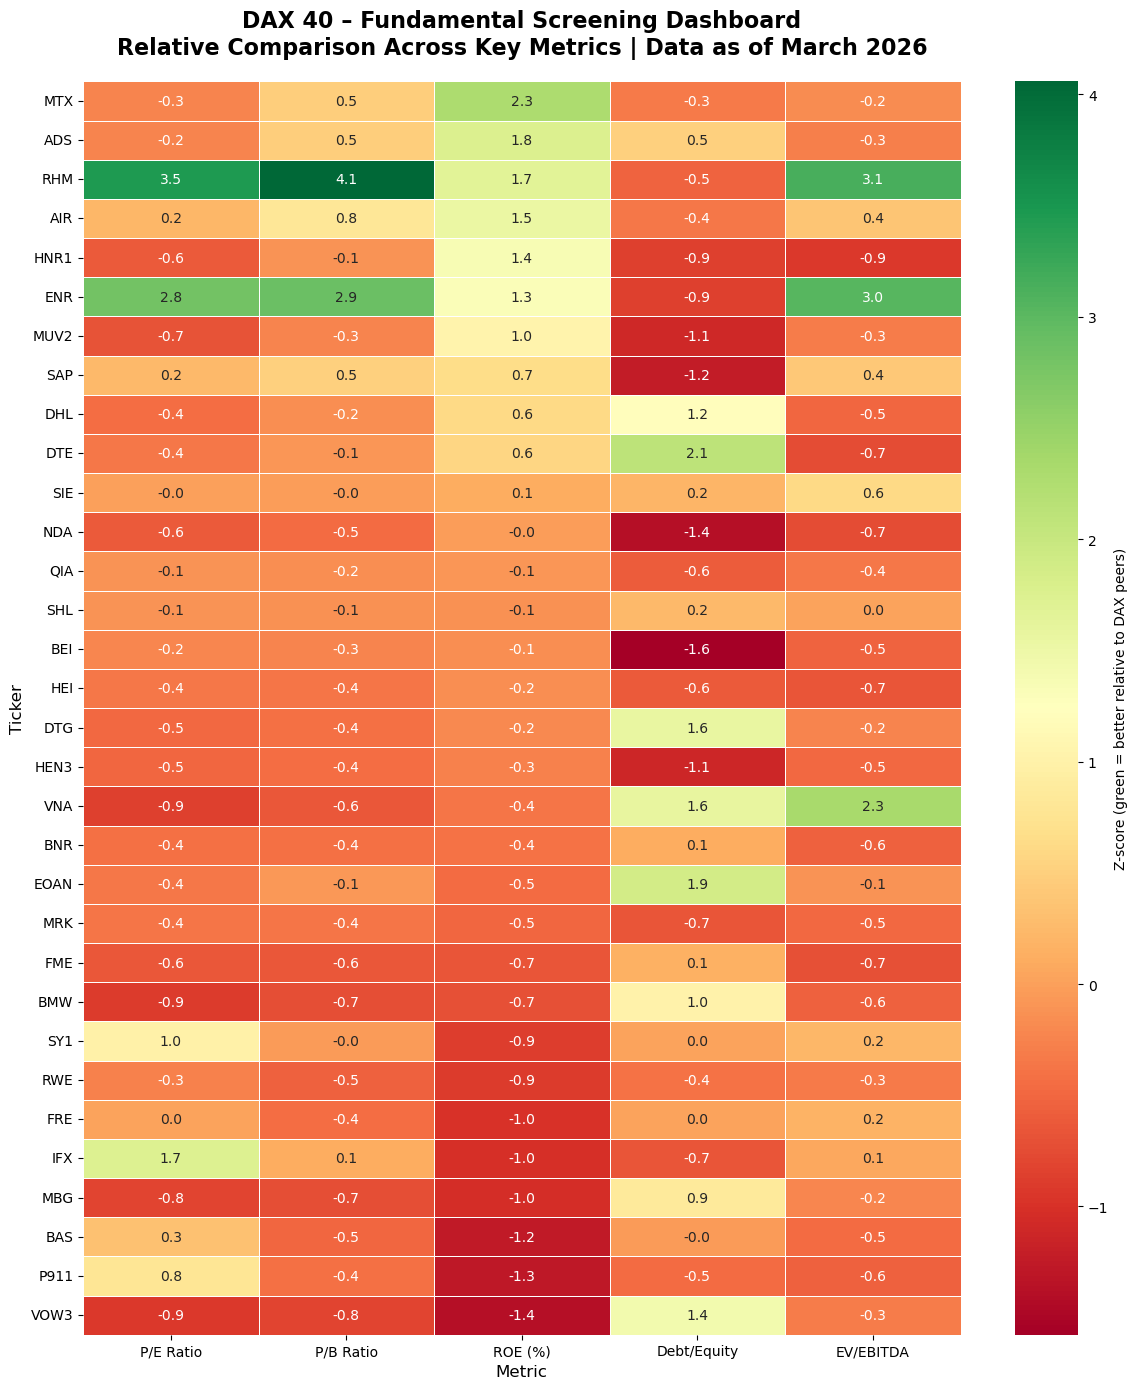

Saved to data/01_fundamental_heatmap.png


In [11]:
metrics = ['P/E Ratio', 'P/B Ratio', 'ROE (%)', 'Debt/Equity', 'EV/EBITDA']
heatmap_data = df_clean[['Ticker'] + metrics].set_index('Ticker')

# Missing values filled with column median – preserves all companies in visual
heatmap_data = heatmap_data.apply(lambda x: x.fillna(x.median()))

# Z-score normalization – allows comparison across metrics with different scales
# Each value = std deviations above/below DAX peer average
# Green = better relative to peers, Red = worse relative to peers
heatmap_normalized = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()

fig, ax = plt.subplots(figsize=(12, 14))

sns.heatmap(
    heatmap_normalized,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Z-score (green = better relative to DAX peers)'}
)

ax.set_title(
    "DAX 40 – Fundamental Screening Dashboard\n"
    "Relative Comparison Across Key Metrics | Data as of March 2026",
    fontsize=16,
    fontweight='bold',
    pad=20
)
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Ticker", fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('data/01_fundamental_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to data/01_fundamental_heatmap.png")